In [52]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model

In [62]:
# Parametre
latent_dim = 100
batch_size = 2048
epochs = 100
sample_interval = 10

In [63]:
mnist_path = r"data/mnist.npz" 
with np.load(mnist_path, allow_pickle=True) as f:
    x_train = f['x_train']

# Normalizasyon [-1,1]
x_train = x_train / 127.5 - 1.0

# Kanal boyutu ekle (28,28,1)
x_train = np.expand_dims(x_train, axis=-1)

# TensorFlow Dataset oluştur
dataset = tf.data.Dataset.from_tensor_slices(x_train)\
                         .shuffle(buffer_size=1024)\
                         .batch(batch_size)


In [64]:
# Generator

In [65]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(7*7*128, input_dim=latent_dim),
        layers.Reshape((7, 7, 128)),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding="same", activation="tanh")
    ])
    return model

In [66]:
# Discriminator

In [67]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, kernel_size=4, strides=2, padding="same", input_shape=(28,28,1)),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(), 
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

In [68]:
# GAN modeli oluştur

In [69]:

def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, kernel_size=4, strides=2, padding="same", input_shape=(28,28,1)),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model
generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

z = layers.Input(shape=(latent_dim,))
img = generator(z)
discriminator.trainable = False
valid = discriminator(img)
gan = Model(z, valid)
gan.compile(loss="binary_crossentropy", optimizer="adam")


10 [D loss: 0.7458, acc.: 8.14%] [G loss: 0.6557]


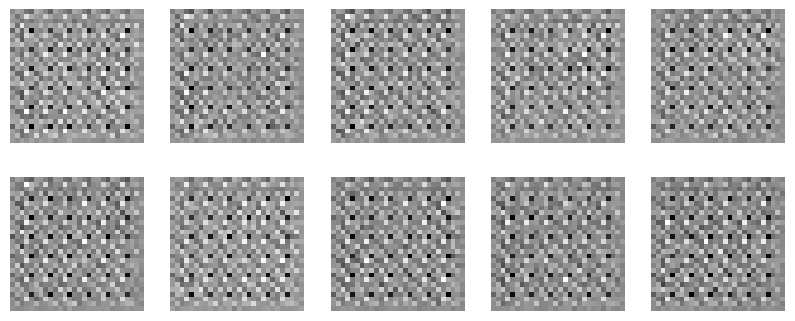

20 [D loss: 0.7554, acc.: 4.06%] [G loss: 0.5941]


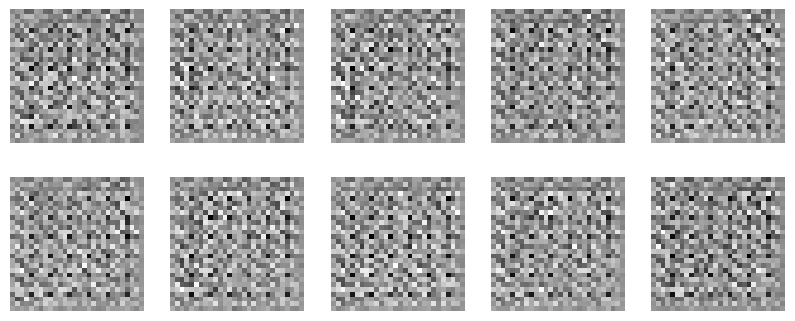

30 [D loss: 0.7742, acc.: 2.73%] [G loss: 0.5310]


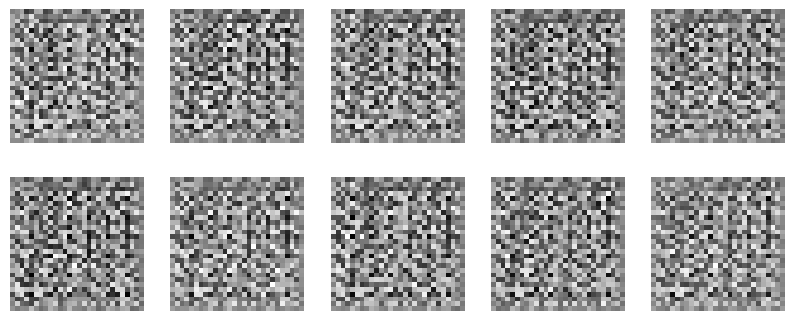

40 [D loss: 0.8001, acc.: 2.07%] [G loss: 0.4802]


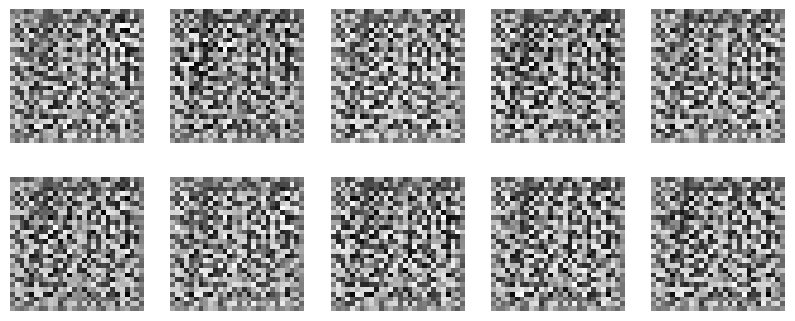

50 [D loss: 0.8276, acc.: 1.66%] [G loss: 0.4423]


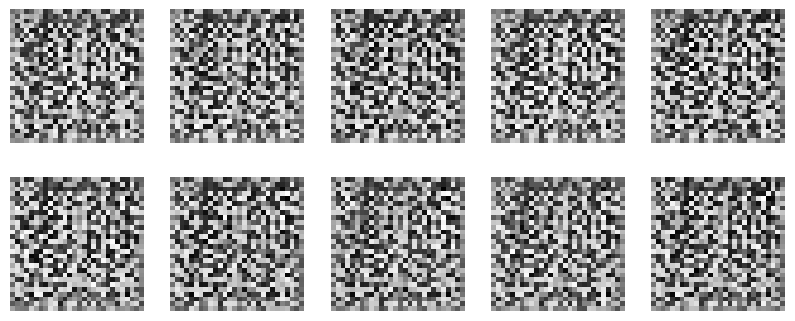

60 [D loss: 0.8534, acc.: 1.40%] [G loss: 0.4140]


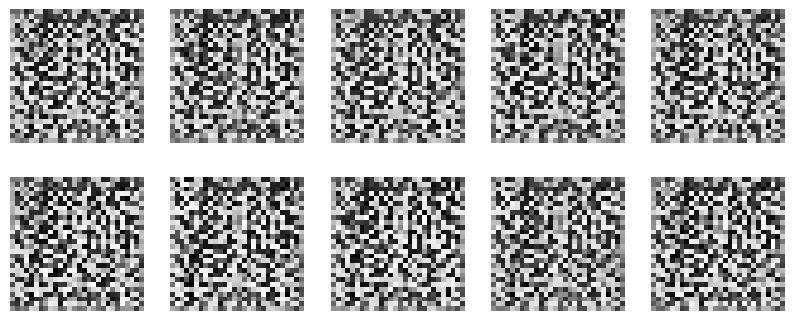

70 [D loss: 0.8767, acc.: 1.21%] [G loss: 0.3923]


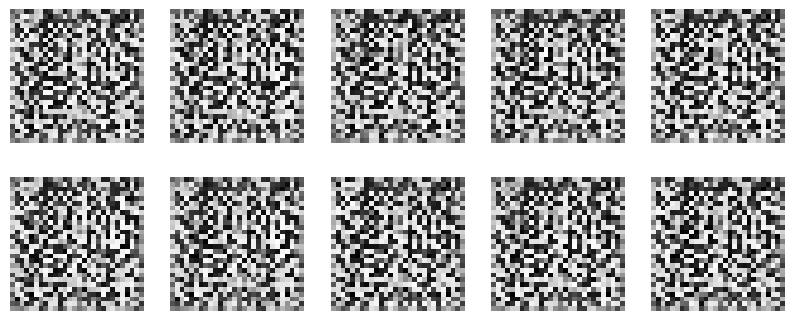

80 [D loss: 0.8975, acc.: 1.07%] [G loss: 0.3749]


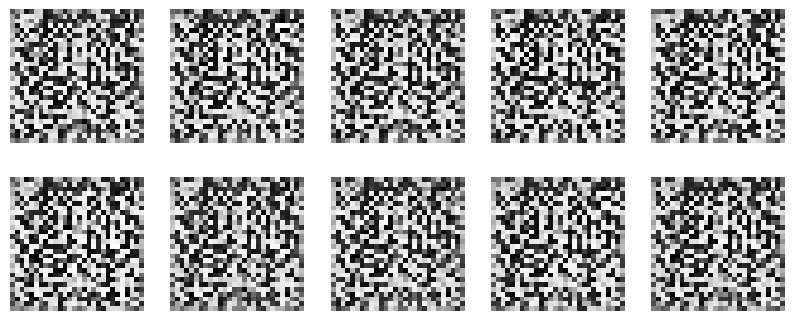

90 [D loss: 0.9162, acc.: 0.96%] [G loss: 0.3608]


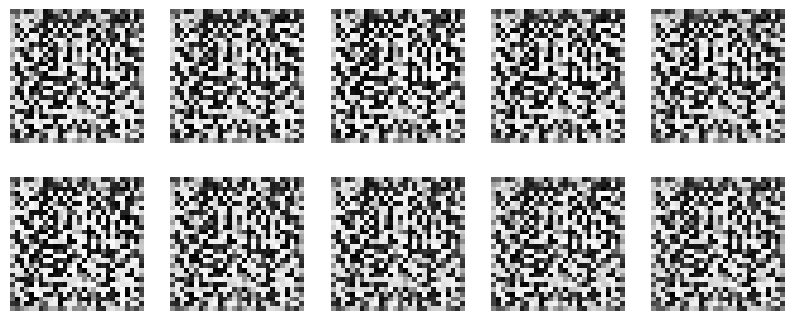

100 [D loss: 0.9330, acc.: 0.87%] [G loss: 0.3490]


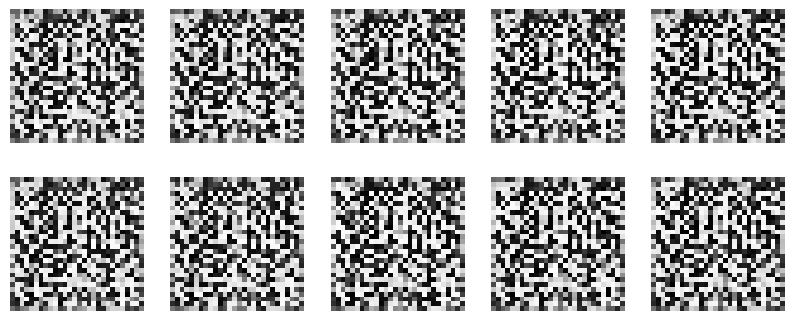

In [70]:
for epoch in range(1, epochs+1):
    # Gerçek görüntüler
    real_imgs = next(iter(dataset))
    batch_size_curr = real_imgs.shape[0]

    # Gürültüden sahte görüntü üret
    noise = np.random.normal(0, 1, (batch_size_curr, latent_dim))
    fake_imgs = generator.predict(noise, verbose=0)

    # Discriminator eğitimi
    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size_curr, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size_curr, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)  # ortalama loss

    # Generator eğitimi (discriminator donmuş durumda)
    noise = np.random.normal(0, 1, (batch_size_curr, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size_curr, 1)))

    # Belirli aralıklarla çıktı göster
    if epoch % sample_interval == 0:
        print(f"{epoch} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")

        r, c = 2, 5
        noise = np.random.normal(0, 1, (r * c, latent_dim))
        gen_imgs = generator.predict(noise, verbose=0)
        gen_imgs = 0.5 * gen_imgs + 0.5  # [0,1] aralığına getir

        fig, axs = plt.subplots(r, c, figsize=(10, 4))
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i, j].imshow(gen_imgs[cnt, :, :, 0], cmap="gray")
                axs[i, j].axis("off")
                cnt += 1
        plt.show()